In [2]:
%pip install -q langgraph langchain-openai langchain-core pydantic rapidfuzz python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

In [4]:
MODEL = "gpt-4.1"

In [10]:
import os
from dotenv import load_dotenv

load_dotenv()  # take environment variables from .env.
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

MODEL = "gpt-4o-mini"   # fine for dev; bump to "gpt-4o" later for best date reasoning

In [11]:
llm = ChatOpenAI(model=MODEL)

#### Extraction Agent's Schema

In [5]:
from __future__ import annotations
from typing import List, Optional
from pydantic import BaseModel, Field


class Decision(BaseModel):
    decision: str = Field(description="the decision that was made or agreed")
    source_ids: List[int] = Field(description="transcript line ids supporting this, e.g. [7, 3, 12...]")
    # source_excerpt: str = Field(description="short verbatim quote copied from those exact lines")
    # ↓ system-filled by the grounding step — the LLM should leave these
    evidence: str = ""
    citation_verified: bool = False


class ActionItem(BaseModel):
    task: str = Field(description="the task to be done")
    owner: Optional[str] = Field(default=None, description="person responsible; null if not clearly stated")
    start: Optional[str] = Field(default=None, description="start date as YYYY-MM-DD if stated/implied, resolved against the anchor date; else null")
    due: Optional[str] = Field(default=None, description="due date as YYYY-MM-DD, resolved against the anchor date; else null")
    source_ids: List[int] = Field(description="transcript line ids supporting this, e.g. [1, 3, 5...]")
    # source_excerpt: str = Field(description="short verbatim quote from those lines")
    evidence: str = ""
    citation_verified: bool = False


class Blocker(BaseModel):
    blocker: str = Field(description="what is blocking progress")
    source_ids: List[int] = Field(description="transcript line ids supporting this, e.g. [4, 2, 6...]")
    # source_excerpt: str = Field(description="short verbatim quote from those lines")
    evidence: str = ""
    citation_verified: bool = False


class ExtractionResult(BaseModel):
    """What the extraction agent returns."""
    tag: str = Field(description="one short line hinting what the call was about")
    summary: str = Field(description="3-6 sentence neutral summary")
    recommended_next_steps: List[str] = Field(default_factory=list)
    decisions: List[Decision] = Field(default_factory=list)
    action_items: List[ActionItem] = Field(default_factory=list)
    blockers: List[Blocker] = Field(default_factory=list)

#### turning a raw transcript into the numbered L001… lines these source_ids point at (the thing that makes grounding possible).

#### So grounding becomes: IDs must exist → rebuild evidence from those lines → if any ID is bogus, flag for review.

In [6]:
from datetime import date

def ingest(raw: str, meeting_date: date | str | None = None):
    if meeting_date is None:
        anchor = date.today()
    elif isinstance(meeting_date, str):
        anchor = date.fromisoformat(meeting_date)
    else:
        anchor = meeting_date

    segments = []
    idx = 0
    for line in raw.splitlines():
        stripped = line.strip()
        if not stripped or stripped.startswith("#"):
            continue
        idx += 1
        segments.append({"id": idx, "text": stripped})   # <-- plain int

    lookup = {s["id"]: s for s in segments}
    meta = {
        "anchor_date": anchor.isoformat(),
        "anchor_weekday": anchor.strftime("%A"),
        "anchor_source": "provided" if meeting_date else "today (default)",
        "segment_count": len(segments),
    }
    return segments, lookup, meta

In [8]:
sample = """[00:01] Mira (Lead): Quick sync. Raj, where's the payments webhook?
[00:07] Raj: I'll have it done by this week Wednesday. Testing is all that's left.
[00:14] Mira: Any blockers?
[00:16] Raj: I'm blocked on staging keys, I don't have access yet.
[00:21] Mira: We'll go with Postgres full-text for now instead of Elasticsearch.
[00:28] Devi: Agreed. I'll ship the reindex by end of next week.
"""

# pass the meeting date as an input variable; try None to see it fall back to today
segments, lookup, meta = ingest(sample, meeting_date="2026-07-01")

print("META:", meta, "\n")
for s in segments:
    print(f"{s['id']}  {s['text']}")

META: {'anchor_date': '2026-07-01', 'anchor_weekday': 'Wednesday', 'anchor_source': 'provided', 'segment_count': 6} 

1  [00:01] Mira (Lead): Quick sync. Raj, where's the payments webhook?
2  [00:07] Raj: I'll have it done by this week Wednesday. Testing is all that's left.
3  [00:14] Mira: Any blockers?
4  [00:16] Raj: I'm blocked on staging keys, I don't have access yet.
5  [00:21] Mira: We'll go with Postgres full-text for now instead of Elasticsearch.
6  [00:28] Devi: Agreed. I'll ship the reindex by end of next week.


## Domain Registry

In [14]:
def numbered(segments) -> str:
    """Render segments as 'id: text' lines — this is what the LLM cites against."""
    return "\n".join(f"{s['id']}: {s['text']}" for s in segments)


DOMAINS = {
    "debt_collection": {
        "description": "A debt collector/agency contacting a consumer to collect or resolve an outstanding balance (credit card, auto, medical, etc.).",
        "context": """US debt-collection call (FDCPA-adjacent). Watch for:
- Missing Tape Disclosure (call is being recorded) and mini-Miranda statement before sharing any debt related information ("this is an attempt to collect a debt and any information obtained will be used for that purpose").
- Identity verification (Full Name) BEFORE sharing account details.
- Check if there any third party debt disclosure (sharing someone's debt with someone else is prohibited).
- RED: third party disclosure, account details before verification; missing tape disclosure and mini-Miranda; threats or
  misleading statements; full SSN spoken aloud, FDCPA violations. 
- YELLOW: settlement/waiver promised above the settlement authority;
- Keep in mind: a promise-to-pay is an action item (owner = agent needs to follow up on agreed dates); any
  settlement above 50 percent discount/waiver needs supervisor approval -> human judgment; any post dated payments or part payments scheduled for future dates are action items (owner = agent needs to follow up on agreed dates); 
  Mark account as 'paid in full' or 'settled' if full balance or settlement amount is paid then and there and close these accounts to stop further collection activity. If the account is disputed, mark as 'disputed' and forward to the dispute team for further investigation.""",
    },

    "sales": {
        "description": "A sales rep engaging a prospect or existing customer to qualify, demo, price, negotiate, or close — including renewals and upsells.",
        "context": """B2B/B2C sales call (discovery / demo / negotiation / closing). Watch for:
- Discovery captured: prospect's pain, current tooling, team size/seats, timeline, and budget authority (who signs off).
- Pricing stated clearly: list price vs quoted price, discount %, contract term, and whether it's verbal or in writing.
- RED: pricing/discount/term commitments made BEYOND the rep's discount authority without manager approval; guarantees about unshipped features or delivery dates ("it'll definitely ship next month"); claims about competitors or other customers' data that can't be substantiated; verbal side-agreements not reflected in the contract.
- YELLOW: discount discussed but final number left fuzzy; next step agreed with no owner or date; single-threaded deal (only one contact, no economic buyer engaged); ROI/pricing quoted from memory rather than the approved price book.
- Keep in mind: "we'll go with the Pro plan" is a DECISION; sending the proposal/order form/DPA and looping in procurement or legal are ACTION ITEMS (owner = rep unless stated otherwise) — resolve their dates. A discount above the rep's authority threshold needs manager/deal-desk approval -> human judgment. Blockers are usually procurement sign-off, security/legal review, or budget approval; capture them as blockers, not decisions. Track the agreed next meeting as an action item with a date.""",
    },

    "customer_support": {
        "description": "An existing customer contacting support about a problem, request, billing issue, or escalation.",
        "context": """Customer support / service call (issue -> troubleshoot -> resolution or escalation). Watch for:
- Verification appropriate to the action: identity/account ownership confirmed before account changes, refunds, or sharing account data.
- Issue and resolution captured: what broke, what was done, and what was promised (refund, replacement, credit, callback, timeline/SLA).
- RED: sensitive data (full card number, SSN, DOB, passwords, OTPs) read aloud or asked for insecurely; account changes/refunds processed without verifying ownership; commitments (refund amount, "fixed by tomorrow", SLA) made without authority or system confirmation; PII shared with a third party / wrong account.
- YELLOW: consent to record unclear; resolution promised but system/tool status uncertain ("I think our refund system is back up"); no ticket/case number created; customer dissatisfied and churn/complaint risk not flagged; workaround given without a real fix.
- Keep in mind: a promised refund/credit, a callback, opening or escalating a ticket, and a follow-up are all ACTION ITEMS (owner = agent) — resolve their dates. Note explicitly when the agent LACKS authority to do what the customer wants -> escalation / human judgment. A confirmed fix or approved refund is a DECISION; an unresolved dependency (outage, waiting on another team) is a BLOCKER. Capture the case/ticket number if one is mentioned.""",
    },
}

# general_meeting is the implicit fallback and has NO context (handled below)
def get_domain_context(domain: str) -> str:
    d = DOMAINS.get(domain)
    return d["context"] if d else ""

### Domain Classifier 
#### Classify Domains from call transcript text, e.g. "sales", "debt collection", "customer support", "internal team meeting", etc. This is used to select the right domain-specific prompt for the extraction agent.

In [12]:
from typing import Optional
from pydantic import BaseModel, Field, create_model

# The router is told, at call time, which domains exist + their descriptions.
# The system prompt itself is domain-agnostic, so your future web app can add
# domains to the registry without touching this prompt.
ROUTER_SYSTEM = """You are a call/meeting classifier.

You will be given a numbered transcript and a list of candidate domains, each with a short description. Read the transcript and decide which single domain it best fits.

Rules:
- Choose exactly one domain from the provided list.
- Base the decision on what the conversation actually is (who the speakers are and what they're doing), not on isolated keywords.
- If the transcript does not clearly fit any provided domain, return "general_meeting".
- Give a one-sentence rationale."""

def _domain_menu() -> str:
    lines = [f"- {name}: {d['description']}" for name, d in DOMAINS.items()]
    lines.append("- general_meeting: none of the above / internal team meeting or unclear.")
    return "\n".join(lines)

def classify_domain(segments):
    # allowed values = registry keys + the fallback, built dynamically
    allowed = tuple(DOMAINS.keys()) + ("general_meeting",)
    Classification = create_model(
        "Classification",
        domain=(str, Field(description=f"one of: {', '.join(allowed)}")),
        rationale=(str, Field(description="one short sentence")),
    )
    router = llm.with_structured_output(Classification)
    result = router.invoke([
        ("system", ROUTER_SYSTEM),
        ("human", f"CANDIDATE DOMAINS:\n{_domain_menu()}\n\nTRANSCRIPT:\n{numbered(segments)}"),
    ])
    # guard: if the model returns something off-list, fall back
    if result.domain not in allowed:
        result.domain = "general_meeting"
    return result

#### Testing the domain classifier on a sample transcript to see if it correctly identifies the domain.

In [15]:
tests = {
"debt_collection": """[00:00] Agent: Thank you for calling back, this call is recorded for quality and compliance. This is Marcus with Anderson Recovery — this is an attempt to collect a debt and any information obtained will be used for that purpose. Am I speaking with James Whitfield?
[00:09] Consumer: Yeah, this is James.
[00:11] Agent: Thanks. To verify, can you confirm your full name and the last four of your SSN?
[00:16] Consumer: James Whitfield, and it's 4412.
[00:20] Agent: Perfect. James, our records show a past-due balance of $2,340 on your Summit Card account. How can we take care of that today?
[00:28] Consumer: I honestly can't do the full amount. I lost my job in March.
[00:33] Agent: I understand. I may be able to offer a settlement. If you can do $1,400 today we can consider it settled in full.
[00:41] Consumer: That's still too much right now. Could I do $700 now and $700 next month?
[00:47] Agent: Let me note that — $700 today and $700 on the 15th of next month. I'll need a supervisor to approve the settlement split, I'll follow up by Friday.
[00:56] Consumer: Okay. And this won't go on my credit as unpaid?
[01:00] Agent: Once both payments post, we'll mark it settled and close the account. I'll send written confirmation.""",

"sales": """[00:00] Rep: Thanks for hopping on, Dana. Last time your team was hitting limits on the Starter plan — did the dashboards help since the trial?
[00:08] Dana: They did. The analytics are the main reason we'd move forward. We've got about 30 people who'd need seats now.
[00:15] Rep: Got it. For 30 seats I'd put you on Pro. List is $40 a seat, but I can do $32 if we sign an annual term.
[00:23] Dana: Pricing's the sticking point. Anything over $25k a year has to clear procurement, and legal needs to review the data terms.
[00:31] Rep: Understood. Let's plan on Pro at the annual rate, pending those approvals. I'll send the proposal and the DPA today and loop in our security team for the review.
[00:40] Dana: Who's chasing procurement on your side?
[00:42] Rep: That'd be on your side actually — can someone there own it, otherwise it'll stall?
[00:47] Dana: I'll find out who. Let's regroup early next week.
[00:50] Rep: Perfect, I'll set up the follow-up and aim to have everything wrapped by end of the month.""",

"customer_support": """[00:00] Agent: Thanks for calling TechCare support, this is Priya, is it alright if I record this call for quality?
[00:06] Customer: Sure. I've been charged twice for my subscription this month and I want it fixed.
[00:12] Agent: I'm sorry about that. Let me pull up your account — can you confirm the email and billing zip on file?
[00:19] Customer: jordan.k@example.com, zip 60614.
[00:24] Agent: Thank you, that verifies you. I do see two charges on the 3rd. That's a duplicate on our end, so a refund is warranted.
[00:32] Customer: Good. How fast?
[00:34] Agent: Normally three to five business days. I'll be honest though — our billing tool's been flaky since yesterday's outage, so I can't fully confirm it processed.
[00:43] Customer: That's not reassuring. I need this resolved.
[00:46] Agent: I hear you. I don't have authority to expedite the refund myself, so I'm opening a priority ticket — case 55231 — and escalating to billing. I'll personally follow up with you tomorrow to confirm it went through.""",

"general_meeting": """[00:00] Mira: Quick standup. Raj, where's the payments webhook?
[00:04] Raj: I'll have the Stripe handler done by this week Wednesday, just testing left. I'm blocked on staging keys though, no access yet.
[00:12] Mira: I'll chase IT for your access today. Devi, the search reindex?
[00:17] Devi: Script's ready. I'll run it in prod this weekend, but our rule is prod changes need a second reviewer — not sure who's free.
[00:25] Mira: We'll go with Postgres full-text for now instead of Elasticsearch, the extra infra isn't worth it yet.
[00:31] Devi: Agreed. I'll aim to ship the reindex by end of next week if I get a reviewer.
[00:36] Mira: Last thing — the flaky CI. Someone should look at it soon, it's slowing everyone down.""",
}

for expected, text in tests.items():
    segs, _, _ = ingest(text, meeting_date="2026-07-01")
    r = classify_domain(segs)
    ok = "✓" if r.domain == expected else "✗"
    print(f"{ok}  expected={expected:18s} got={r.domain:18s} | {r.rationale}")

✓  expected=debt_collection    got=debt_collection    | The conversation involves a debt collector attempting to collect a past-due balance from a consumer.
✓  expected=sales              got=sales              | This conversation involves a sales representative discussing pricing and contract details with a prospective customer, indicating it is a sales interaction.
✓  expected=customer_support   got=customer_support   | The dialogue involves an existing customer contacting support regarding a billing issue related to their subscription.
✓  expected=general_meeting    got=general_meeting    | The conversation is a technical standup meeting discussing project progress and blockers among team members.


## Extraction agent
This is the generic, domain-agnostic extractor. It does three jobs at once: pull the structured items, resolve fuzzy dates into real YYYY-MM-DD using the anchor, and cite line numbers for grounding. The prompt is written to work for any domain — the domain context is injected as optional reference, not baked in.

In [16]:
EXTRACTION_SYSTEM = """You extract structured intelligence from a numbered meeting/call transcript. You are precise and conservative: you never invent facts, owners, or dates.

TRANSCRIPT FORMAT
Each line is "<id>: <text>", where <id> is the integer line number. That id is the ONLY way to cite evidence.

GROUNDING (hard rules)
- Every decision, action item, and blocker MUST include source_ids: the integer line id(s) that directly support it. Cite the minimum lines needed.
- Only cite ids that exist in the transcript. Never guess an id.
- If something is implied but not actually stated (e.g. an owner is never named), leave that field null. Do NOT guess — a human-review step exists for gaps.

DATES (use temporal reasoning)
- You are given ANCHOR_DATE (the meeting date) and its weekday. Resolve every relative or fuzzy date expression against that anchor and output a concrete calendar date in YYYY-MM-DD.
  Examples given anchor Wednesday 2026-07-01: "this week Wednesday" -> 2026-07-01; "Friday" -> 2026-07-03; "end of next week" -> 2026-07-10; "the 15th of next month" -> 2026-08-15; "tomorrow" -> 2026-07-02; "in two weeks" -> 2026-07-15.
- For action items, set `start` and/or `due` only when a time is stated or clearly implied; otherwise null. If only one date is mentioned, treat it as `due`. Do not output a date you could not derive from the transcript.
- If a date phrase is too vague to resolve to a single day (e.g. "sometime soon", "in the coming weeks"), leave the date null (a human will follow up).

WHAT TO EXTRACT
- tag: one short line hinting what the call was about.
- summary: 3-6 neutral sentences.
- recommended_next_steps: short actionable follow-ups.
- decisions: things actually agreed/decided (not mere discussion).
- action_items: task + owner (or null) + start/due (or null) + source_ids.
- blockers: things stopping progress (dependencies, waiting-on, unresolved issues).

Distinguish a DECISION ("we'll go with X") from an ACTION ITEM ("I'll do X by Friday") from a BLOCKER ("we can't do X until Y"). Use the domain context, if provided, only as guidance on what matters in this kind of call — do not force items that aren't there.

Return the structured object only."""

def extract(segments, domain_context: str, meta) -> ExtractionResult:
    extractor = llm.with_structured_output(ExtractionResult)
    ctx = domain_context.strip() or "(none — general meeting, no special domain rules)"
    user = (
        f"ANCHOR_DATE: {meta['anchor_date']} ({meta['anchor_weekday']})\n"
        f"Resolve all relative dates against this anchor.\n\n"
        f"DOMAIN CONTEXT (reference only, do not quote as transcript):\n{ctx}\n\n"
        f"NUMBERED TRANSCRIPT:\n{numbered(segments)}"
    )
    return extractor.invoke([("system", EXTRACTION_SYSTEM), ("human", user)])

###  run it on the sales transcript and inspect (dates + grounding):

In [17]:
import json

text = tests["sales"]
segments, lookup, meta = ingest(text, meeting_date="2026-07-01")
domain = classify_domain(segments).domain
ctx = get_domain_context(domain)

result = extract(segments, ctx, meta)

print(f"domain={domain}  anchor={meta['anchor_date']} ({meta['anchor_weekday']})\n")
print("TAG:", result.tag)
print("SUMMARY:", result.summary, "\n")

print("DECISIONS")
for d in result.decisions:
    print(f"  • {d.decision}   ⟵ lines {d.source_ids}")

print("\nACTION ITEMS")
for a in result.action_items:
    print(f"  • {a.task}")
    print(f"      owner={a.owner}  start={a.start}  due={a.due}  ⟵ lines {a.source_ids}")

print("\nBLOCKERS")
for b in result.blockers:
    print(f"  • {b.blocker}   ⟵ lines {b.source_ids}")

domain=sales  anchor=2026-07-01 (Wednesday)

TAG: Discussion on pricing and procurement processes
SUMMARY: The call involved a discussion around moving Dana's team from the Starter plan to the Pro plan, which would require about 30 seats. The representative quoted a price of $32 per seat annually, totaling just over $25,000, which flagged the need for procurement and legal approvals. Dana mentioned that anything over $25,000 needs to clear procurement. The rep agreed to send the proposal and a Data Processing Agreement (DPA) and also stressed the importance of someone from Dana's team owning the procurement process to avoid delays. They planned to regroup early next week. 

DECISIONS
  • They'll proceed with Pro plan at $32 per seat pending approvals   ⟵ lines [3, 4]

ACTION ITEMS
  • Send proposal and DPA
      owner=Rep  start=2026-07-01  due=2026-07-01  ⟵ lines [5]
  • Schedule follow-up meeting
      owner=Rep  start=None  due=2026-07-05  ⟵ lines [8]

BLOCKERS
  • Need procurement 

quick grounding pre-check (do the cited ids actually exist?):

In [18]:
valid_ids = set(lookup)
for kind, items in [("decision", result.decisions),
                    ("action", result.action_items),
                    ("blocker", result.blockers)]:
    for it in items:
        bad = [i for i in it.source_ids if i not in valid_ids]
        label = getattr(it, kind if kind != "action" else "task")
        flag = f"⚠ bogus ids {bad}" if bad else "✓ ids valid"
        print(f"{flag:20s} [{kind}] {label[:60]}")

✓ ids valid          [decision] They'll proceed with Pro plan at $32 per seat pending approv
✓ ids valid          [action] Send proposal and DPA
✓ ids valid          [action] Schedule follow-up meeting
✓ ids valid          [blocker] Need procurement approval for pricing above $25k
✓ ids valid          [blocker] Unclear who from Dana's team will own the procurement proces


Here are the expected outputs for all four test calls transcripts — what a good real-mode run *should* produce. 
## Expected outputs

**debt_collection** (`$700 now + $700 on the 15th of next month`, settlement split pending approval)
- **tag:** Collections call — Summit Card past-due, settlement split negotiated
- **decisions:** none firm yet — the settlement split is *pending supervisor approval*, so it should be a blocker/action, not a decision. (A model that logs "account will be marked settled once both payments post" as a conditional decision is acceptable.)
- **action items:**
  - `task`: Consumer to pay $700 today · `owner`: James (consumer) · `due`: **2026-07-01** · lines cite the "$700 now" line
  - `task`: Consumer to pay $700 second installment · `owner`: James · `due`: **2026-08-15** ← the sharp date test ("15th of next month")
  - `task`: Follow up on / get supervisor approval for the settlement split · `owner`: Marcus (agent) · `due`: **2026-07-03** (Friday) · cites the "follow up by Friday" line
  - `task`: Send written confirmation of settlement · `owner`: Marcus (agent) · `due`: null
- **blockers:** Settlement split requires supervisor approval before it's final
- **human-review flavor (Step 6 later):** settlement offered → check it's within authority (your context says >50% needs approval); verification used last-4 of SSN (fine); tape disclosure + mini-Miranda **present** (good, not a flag)

**sales** (Pro plan pending approvals; owner-less procurement task)
- **tag:** Sales call — Pro plan for ~30 seats, pricing pending approvals
- **decisions:** Go with **Pro plan at the annual rate ($32/seat), pending procurement + legal approval**
- **action items:**
  - `task`: Send proposal + DPA · `owner`: Rep · `due`: **2026-07-01** (today)
  - `task`: Loop in security team for the data-terms review · `owner`: Rep · `due`: null
  - `task`: Chase procurement sign-off · `owner`: **null** ← the "don't guess owner" test (Dana said "I'll find out who")
  - `task`: Regroup / follow-up meeting · `owner`: Rep · `due`: **2026-07-06** (early next week) · *acceptable range Mon 07-06*
  - `task`: Have everything wrapped · `owner`: Rep · `due`: **2026-07-31** (end of the month)
- **blockers:** Procurement sign-off (spend >$25k); Legal review of data terms

**customer_support** (duplicate charge; refund promised without authority; shaky system)
- **tag:** Support call — duplicate subscription charge, refund escalated
- **decisions:** Refund is warranted (duplicate charge confirmed on the 3rd)
- **action items:**
  - `task`: Open priority ticket (case 55231) and escalate to billing · `owner`: Priya (agent) · `due`: 2026-07-01
  - `task`: Follow up with customer to confirm refund processed · `owner`: Priya · `due`: **2026-07-02** (tomorrow)
- **blockers:** Billing tool unreliable after outage — refund can't be confirmed; agent lacks authority to expedite
- **human-review flavor:** full card number **not** read aloud here (good); consent to record = "Sure" (clear); the *unauthorized-refund + can't-confirm-system* combo is the escalation

**general_meeting** (owner-less reindex, vague "soon")
- **tag:** Eng standup — payments webhook, search reindex, CI
- **decisions:** Use **Postgres full-text** instead of Elasticsearch for now
- **action items:**
  - `task`: Finish Stripe webhook handler · `owner`: Raj · `due`: **2026-07-01** (this week Wednesday = the anchor itself)
  - `task`: Chase IT for Raj's staging access · `owner`: Mira · `due`: 2026-07-01 (today)
  - `task`: Run search reindex in prod · `owner`: Devi · `due`: **2026-07-10** (end of next week) · *conditional on a reviewer*
  - `task`: Look at flaky CI · `owner`: **null** · `due`: **null** ← "someone should look at it soon" = no owner, unresolvable date
- **blockers:** Raj blocked on staging keys/access; reindex blocked pending a second reviewer

## Compliance / Human Review agent
This is the second LLM pass: it reads the transcript with the domain context as the rulebook and produces compliance observations (Red/Yellow) plus items needing human review — each grounded to line numbers. For general_meeting (no context) it leans on general judgment and will usually return little, which is correct.

In [19]:
from typing import List, Literal
from pydantic import BaseModel, Field

class ComplianceObservation(BaseModel):
    note: str = Field(description="what the issue is and why it matters; reference the domain rule if one applies")
    status: Literal["Red", "Yellow", "Green"] = Field(description="Red=likely violation/serious risk; Yellow=coaching/soft risk; Green=a required step was correctly followed")
    source_ids: List[int]
    evidence: str = ""

class ReviewItem(BaseModel):
    item: str = Field(description="the specific thing a human should look at")
    reason: str = Field(description="why it needs a human")
    category: str = Field(description="a short free-form label for the kind of issue (you choose it)")
    source_ids: List[int]
    evidence: str = ""

class ReviewResult(BaseModel):
    compliance_observations: List[ComplianceObservation] = Field(default_factory=list)
    items_needing_human_review: List[ReviewItem] = Field(default_factory=list)

COMPLIANCE_SYSTEM = """You are a QA & compliance reviewer for a meeting/call transcript. Read the numbered transcript and surface (a) compliance observations and (b) anything a human should review. Use the DOMAIN CONTEXT, when provided, as your rulebook; otherwise use general good judgment.

GROUNDING (hard rules)
- Every observation and review item MUST cite source_ids (integer line numbers) that support it. Only cite ids that actually exist. Do not speculate beyond what the lines show.

COMPLIANCE OBSERVATIONS
- Red: a likely violation or serious risk (per the domain rules if given, else general standards).
- Yellow: a coaching issue or soft risk worth a human glance.
- Green (optional): note where a required step was correctly followed.

ITEMS NEEDING HUMAN REVIEW
Flag anything that is uncertain, risky, or beyond what an AI should decide on its own. This is open-ended — there are many possible cases. Examples of the KINDS of things to flag (not an exhaustive or fixed list):
- an action item whose deadline is vague, or whose owner/scope/details are missing or unclear;
- a customer/consumer giving unclear or ambiguous consent;
- a possible compliance issue;
- a decision that requires human judgment;
- something the AI does not have the authority or permission to decide or commit to;
- anything unclear or under-specified from the conversation or context;
- sensitive or risky information in the transcript (e.g. personal identifiers, financial data);
- any other situation where a reasonable reviewer would want a human to look before acting.

Choose a short, descriptive category label for each item yourself (free text) — do not force items into a fixed set of categories.

Be conservative and specific: cite the lines, explain the concern in one or two sentences, and don't invent problems to fill space. If the call is genuinely clean, return empty lists. Return the structured object only."""

def review(segments, domain_context: str) -> ReviewResult:
    reviewer = llm.with_structured_output(ReviewResult)
    ctx = domain_context.strip() or "(none — general meeting; use general judgment only)"
    user = (
        f"DOMAIN CONTEXT (your rulebook, may be empty):\n{ctx}\n\n"
        f"NUMBERED TRANSCRIPT:\n{numbered(segments)}"
    )
    return reviewer.invoke([("system", COMPLIANCE_SYSTEM), ("human", user)])

In [20]:
# Cell 15 — debt_collection
text = tests["debt_collection"]
segments, lookup, meta = ingest(text, meeting_date="2026-07-01")
domain = classify_domain(segments).domain
rev = review(segments, get_domain_context(domain))
print(f"domain={domain}\nCOMPLIANCE OBSERVATIONS")
for o in rev.compliance_observations:
    print(f"  [{o.status}] {o.note}   ⟵ lines {o.source_ids}")
print("\nITEMS NEEDING HUMAN REVIEW")
for r in rev.items_needing_human_review:
    print(f"  • [{r.category}] {r.item}\n      reason: {r.reason}   ⟵ lines {r.source_ids}")

domain=debt_collection
COMPLIANCE OBSERVATIONS
  [Green] The tape disclosure and mini-Miranda statement were properly provided at the beginning of the call, aligning with FDCPA standards.   ⟵ lines [1]
  [Green] Identity verification was performed correctly before sharing the account details, as the consumer confirmed their full name and last four of their SSN.   ⟵ lines [3, 4]

ITEMS NEEDING HUMAN REVIEW
  • [Supervisor Approval Needed] Settlement agreement with payment plan
      reason: The agent proposed a payment plan which requires supervisor approval due to the settlement amount being above the 50 percent threshold. Human judgment is necessary to assess if the follow-up is completed properly.   ⟵ lines [9]
  • [Sensitive Information Clarification] Clarification on credit reporting
      reason: The consumer asked if the payments would not impact their credit negatively, indicating uncertainty that may need clarification or assurance from compliance standards.   ⟵ lines [10]


###  Grounding (deterministic)
No LLM here — pure Python. This is the anti-hallucination gate. It does two things for every item across both agents: rebuilds evidence from the transcript by ID (so a human always sees the actual cited lines), and checks that every cited ID is real — routing any bogus citation to human review.

In [21]:
def render_evidence(source_ids, lookup) -> str:
    """Authoritative evidence, rebuilt from the transcript by id (not from the LLM)."""
    parts = []
    for sid in source_ids:
        seg = lookup.get(sid)
        if seg is not None:
            parts.append(f"{sid}: {seg['text']}")
    return "  |  ".join(parts)


def ground_item(item, lookup):
    """
    Fill item.evidence from the transcript. Return (bad_ids, valid_ids).
    Works on any of our Pydantic items (they all have .source_ids and .evidence).
    """
    ids = item.source_ids
    bad = [i for i in ids if i not in lookup]
    valid = [i for i in ids if i in lookup]
    item.evidence = render_evidence(valid, lookup)   # only real lines make it into evidence
    return bad, valid


def ground_all(extraction: ExtractionResult, rev: ReviewResult, lookup):
    """
    Ground every item across both agents. Any item citing a non-existent line id
    becomes a human-review item (a fabricated/hallucinated citation).
    Returns the (possibly extended) list of review items.
    """
    review_items = list(rev.items_needing_human_review)

    buckets = [
        ("decision", extraction.decisions),
        ("action item", extraction.action_items),
        ("blocker", extraction.blockers),
        ("compliance observation", rev.compliance_observations),
    ]

    for kind, items in buckets:
        for it in items:
            bad, valid = ground_item(it, lookup)
            if bad:
                # the label field differs per type; grab whichever exists
                label = getattr(it, "decision", None) or getattr(it, "task", None) \
                        or getattr(it, "blocker", None) or getattr(it, "note", None) or kind
                review_items.append(ReviewItem(
                    item=f"{kind}: {label}",
                    reason=f"Cited transcript line(s) {bad} do not exist — citation could not be grounded.",
                    category="unverified_citation",
                    source_ids=valid,               # keep whatever was real
                    evidence=render_evidence(valid, lookup),
                ))

    # also ground the review items themselves (rebuild their evidence)
    for r in review_items:
        _bad, valid = ground_item(r, lookup)

    return review_items

 run the full chain on one transcript and see grounded evidence:

In [22]:
text = tests["debt_collection"]
segments, lookup, meta = ingest(text, meeting_date="2026-07-01")
domain = classify_domain(segments).domain
ctx = get_domain_context(domain)

extraction = extract(segments, ctx, meta)
rev = review(segments, ctx)
review_items = ground_all(extraction, rev, lookup)

print("ACTION ITEMS (now with rebuilt evidence)")
for a in extraction.action_items:
    print(f"  • {a.task}  | owner={a.owner} due={a.due}")
    print(f"      evidence: {a.evidence}")

print("\nCOMPLIANCE (rebuilt evidence)")
for o in rev.compliance_observations:
    print(f"  [{o.status}] {o.note}")
    print(f"      evidence: {o.evidence}")

print(f"\nHUMAN REVIEW ({len(review_items)})")
for r in review_items:
    print(f"  • [{r.category}] {r.item}")
    print(f"      {r.reason}")
    print(f"      evidence: {r.evidence}")

ACTION ITEMS (now with rebuilt evidence)
  • Follow up with the supervisor regarding the approval of the $700 split payment arrangement.  | owner=Agent due=2026-07-03
      evidence: 9: [00:47] Agent: Let me note that — $700 today and $700 on the 15th of next month. I'll need a supervisor to approve the settlement split, I'll follow up by Friday.
  • Send written confirmation to James once both payments post.  | owner=Agent due=None
      evidence: 11: [01:00] Agent: Once both payments post, we'll mark it settled and close the account. I'll send written confirmation.

COMPLIANCE (rebuilt evidence)
  [Green] The agent correctly provided the tape disclosure and mini-Miranda statement at the beginning of the call, which is compliant.
      evidence: 1: [00:00] Agent: Thank you for calling back, this call is recorded for quality and compliance. This is Marcus with Anderson Recovery — this is an attempt to collect a debt and any information obtained will be used for that purpose. Am I speak

prove the gate works: inject a fabricated citation:

In [23]:
# simulate a hallucinated line id (transcript only has ~11 lines)
extraction.action_items[0].source_ids = [999]

review_items = ground_all(extraction, rev, lookup)

print("evidence for the tampered item:", repr(extraction.action_items[0].evidence))  # -> '' (no real line)
unv = [r for r in review_items if r.category == "unverified_citation"]
print(f"\nunverified_citation flags: {len(unv)}")
for r in unv:
    print("  •", r.item, "→", r.reason)

evidence for the tampered item: ''

unverified_citation flags: 1
  • action item: Follow up with the supervisor regarding the approval of the $700 split payment arrangement. → Cited transcript line(s) [999] do not exist — citation could not be grounded.


## Assemble + wire into LangGraph
Two pieces: a final container object, then the graph that runs everything as one call. All the node logic already exists in earlier steps — the graph just sequences it and passes state along.

### The Final Output Schema:

In [24]:
from typing import List, Optional
from pydantic import BaseModel, Field

class MeetingIntelligence(BaseModel):
    tag: str = ""
    domain: str = ""
    anchor_date: str = ""
    summary: str = ""
    recommended_next_steps: List[str] = Field(default_factory=list)
    decisions: List[Decision] = Field(default_factory=list)
    action_items: List[ActionItem] = Field(default_factory=list)
    blockers: List[Blocker] = Field(default_factory=list)
    compliance_observations: List[ComplianceObservation] = Field(default_factory=list)
    items_needing_human_review: List[ReviewItem] = Field(default_factory=list)
    segment_count: int = 0
    domain_rationale: str = ""

### the LangGraph state + nodes

In [25]:
from typing import TypedDict, Optional, List, Dict, Any
from langgraph.graph import StateGraph, START, END

class State(TypedDict, total=False):
    raw_transcript: str
    meeting_date: Optional[str]
    segments: List[Dict[str, Any]]
    lookup: Dict[int, Dict[str, Any]]
    meta: Dict[str, Any]
    domain: str
    domain_rationale: str
    domain_context: str
    extraction: ExtractionResult
    review: ReviewResult
    review_items: List[ReviewItem]
    final: MeetingIntelligence

def n_ingest(s: State) -> State:
    segments, lookup, meta = ingest(s["raw_transcript"], s.get("meeting_date"))
    return {"segments": segments, "lookup": lookup, "meta": meta}

def n_route(s: State) -> State:
    c = classify_domain(s["segments"])
    return {"domain": c.domain, "domain_rationale": c.rationale,
            "domain_context": get_domain_context(c.domain)}

def n_extract(s: State) -> State:
    return {"extraction": extract(s["segments"], s["domain_context"], s["meta"])}

def n_review(s: State) -> State:
    return {"review": review(s["segments"], s["domain_context"])}

def n_ground(s: State) -> State:
    items = ground_all(s["extraction"], s["review"], s["lookup"])
    return {"review_items": items}

def n_assemble(s: State) -> State:
    ex, rev = s["extraction"], s["review"]
    final = MeetingIntelligence(
        tag=ex.tag, domain=s["domain"], anchor_date=s["meta"]["anchor_date"],
        summary=ex.summary, recommended_next_steps=ex.recommended_next_steps,
        decisions=ex.decisions, action_items=ex.action_items, blockers=ex.blockers,
        compliance_observations=rev.compliance_observations,
        items_needing_human_review=s["review_items"],
        segment_count=s["meta"]["segment_count"],
        domain_rationale=s["domain_rationale"],
    )
    return {"final": final}

c:\Users\amrita.mandal\AppData\Local\Programs\Python\Python312\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### build the graph

In [29]:
def build_graph():
    g = StateGraph(State)
    g.add_node("segment_transcript", n_ingest)
    g.add_node("classify_domain",    n_route)
    g.add_node("extract_items",      n_extract)
    g.add_node("review_compliance",  n_review)
    g.add_node("verify_grounding",   n_ground)
    g.add_node("assemble_output",    n_assemble)

    g.add_edge(START, "segment_transcript")
    g.add_edge("segment_transcript", "classify_domain")
    g.add_edge("classify_domain", "extract_items")     # fan out ↓
    g.add_edge("classify_domain", "review_compliance")
    g.add_edge("extract_items", "verify_grounding")     # join ↓
    g.add_edge("review_compliance", "verify_grounding")
    g.add_edge("verify_grounding", "assemble_output")
    g.add_edge("assemble_output", END)
    return g.compile()

app = build_graph()
print("graph compiled ✓")

graph compiled ✓


#### one call, end to end:

In [30]:
def run_pipeline(transcript: str, meeting_date: str | None = None) -> MeetingIntelligence:
    out = app.invoke({"raw_transcript": transcript, "meeting_date": meeting_date})
    return out["final"]

result = run_pipeline(tests["debt_collection"], meeting_date="2026-07-01")

print(f"[{result.domain}]  {result.tag}")
print("anchor:", result.anchor_date, "| segments:", result.segment_count)
print("\nSUMMARY:", result.summary)

print("\nACTION ITEMS")
for a in result.action_items:
    print(f"  • {a.task} | owner={a.owner} due={a.due}")
    print(f"      ⟵ {a.evidence}")

print("\nDECISIONS");     [print(f"  • {d.decision}") for d in result.decisions]
print("\nBLOCKERS");      [print(f"  • {b.blocker}") for b in result.blockers]
print("\nCOMPLIANCE");    [print(f"  [{o.status}] {o.note}") for o in result.compliance_observations]
print(f"\nHUMAN REVIEW ({len(result.items_needing_human_review)})")
for r in result.items_needing_human_review:
    print(f"  • [{r.category}] {r.item} — {r.reason}")

[debt_collection]  Debt settlement discussion
anchor: 2026-07-01 | segments: 11

SUMMARY: The call involved a debt collection agent discussing a past-due balance with a consumer. The agent confirmed the consumer's identity and informed them of the outstanding amount. The consumer expressed difficulty in paying the full amount but proposed a settlement payment plan. The agent indicated that he would need supervisory approval for the proposed payment split and would follow up by a specified date.

ACTION ITEMS
  • Follow up with supervisor for settlement approval regarding $700 now and $700 on 2026-08-15. | owner=Agent due=2026-07-03
      ⟵ 9: [00:47] Agent: Let me note that — $700 today and $700 on the 15th of next month. I'll need a supervisor to approve the settlement split, I'll follow up by Friday.

DECISIONS

BLOCKERS
  • Approval required from supervisor for the settlement split payment plan.

COMPLIANCE
  [Green] The agent correctly included a tape disclosure and mini-Miranda st

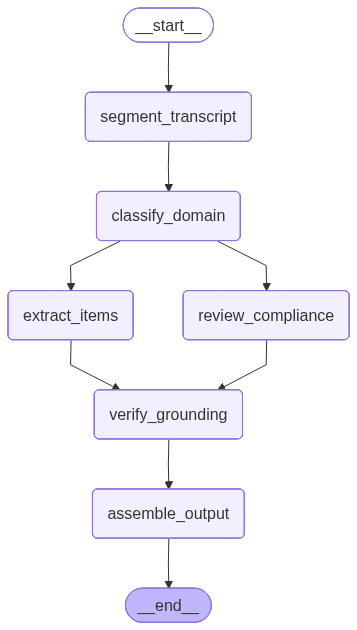

In [31]:
from IPython.display import Image, display

# LangGraph renders its compiled structure to PNG via mermaid
display(Image(app.get_graph().draw_mermaid_png()))

## AssemblyAI transcribe node

In [32]:
%pip install -q assemblyai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import os
import assemblyai as aai
import datetime as dt

aai.settings.api_key = os.getenv("ASSEMBLYAI_API_KEY")  # <-- your AssemblyAI key (or os.environ)
ASSEMBLYAI_MODEL = "universal-2"        # Universal-2

In [34]:
def transcribe_audio(file_path: str) -> dict:
    """Audio file -> diarized transcript. Returns {'transcript': str, 'utterances': list}."""
    config = aai.TranscriptionConfig(
        speech_models=[ASSEMBLYAI_MODEL],
        speaker_labels=True,     # diarization
        format_text=True, punctuate=True, disfluencies=True,
        language_code="en_us", temperature=0,
    )
    config.speech_understanding = {"request": {"custom_formatting": {
        "date": "mm/dd/yyyy", "phone_number": "(xxx)xxx-xxxx",
        "email": "username@domain.com", "format_utterances": True,
    }}}

    transcript = aai.Transcriber(config=config).transcribe(file_path)
    if transcript.status == aai.TranscriptStatus.error:
        raise RuntimeError(f"AssemblyAI failed: {transcript.error}")

    # prefer formatted utterances (phones/dates applied), else standard ones
    raw = transcript.json_response or {}
    fmt = (raw.get("speech_understanding", {}).get("response", {})
              .get("custom_formatting", {}).get("formatted_utterances"))

    lines, utterances = [], []
    source = fmt if fmt else (transcript.utterances or [])
    for u in source:
        spk = (u.get("speaker") if fmt else u.speaker)
        txt = (u.get("text") if fmt else u.text)
        utterances.append({"speaker": f"Speaker {spk}", "text": txt})
        lines.append(f"Speaker {spk}: {txt}")

    if not lines:                                  # very short / silent audio
        lines = [transcript.text or ""]

    return {"transcript": "\n".join(lines), "utterances": utterances}

In [35]:
print(transcribe_audio(r"C:\Users\amrita.mandal\Downloads\Debt Collection Dummy Call.wav"))

ValueError: Please provide an API key via the ASSEMBLYAI_API_KEY environment variable or the global settings.